Trying to reproduce phase diagrams from: 

- [Quantum correlations, entanglement spectrum and coherence of two-particle reduced density matrix in the Extended Hubbard Model](https://arxiv.org/pdf/2111.00085)

- [Formation of spin and charge ordering in the extended Hubbard model during a finite-time quantum quench](https://arxiv.org/pdf/2208.05945)


- [Entanglement of indistinguishable particles as a probe for quantum phase transitions in the extended Hubbard model](https://arxiv.org/pdf/1503.08188)

In [1]:
from __future__ import print_function, division
import sys,os
import numpy as np # type: ignore
import matplotlib.pyplot as plt # type: ignore
import pandas as pd
import matplotlib.cm as cm

from mpl_toolkits.mplot3d import Axes3D

from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib import cbook
import imageio
import os
from scipy.ndimage import gaussian_filter


%matplotlib inline 
font = {
        'weight' : 'bold',
        'size'   : 16}
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')
plt.rc('font', **font) 

figures_path = "../figs"
model = "EHM_Itensor" 
exec = "Phase_Diagram"
results = "../results"
theme = "viridis"

In [3]:
N_Points = 50
L = 5

In [2]:
# Order parameters
def m_SDW(L, Sj): 
    m_sdw = 0
    for j in range(L):
        m_sdw += (-1)**(j) * (Sj[j])
    return m_sdw / L

def m_CDW(L, nj):
    m_cdw = 0
    for j in range(L):
        m_cdw += (-1)**(j) * (nj[j] - 1)
    return m_cdw / L 

In [4]:
def load_scalar_data(results, model, exec, L, N_Points):
    info_input = f"{results}/{model}_{exec}/scalars_{model}_{exec}_L={L}_NPoints={N_Points}.csv"
    df = pd.read_csv(info_input)

    U_vals = np.sort(df['U'].unique())
    V_vals = np.sort(df['V'].unique())

    U_unique = np.sort(df['U'].unique())
    V_unique = np.sort(df['V'].unique())

    nU = len(U_vals)
    nV = len(V_vals)
    
    Q_2 = df['Q_2'].values.reshape(nV, nU).T
    Q_2_bits = df['Q_2_bits'].values.reshape(nV, nU).T

    quantum_coherence_1 = df['coh_1rdm'].values.reshape(nV, nU).T
    quantum_coherence_2 = df['coh_2rdm'].values.reshape(nV, nU).T

    E_p = df['E_p'].values.reshape(nV, nU).T
    E_p_bits = df['E_p_bits'].values.reshape(nV, nU).T
    E_GS = df['E_GS'].values.reshape(nV, nU).T

    m_sdw = abs(df['m_sdw'].values.reshape(nV, nU).T)
    m_cdw = abs(df['m_cdw'].values.reshape(nV, nU).T)

    avg_linear_entropy = df['S'].values.reshape(nV, nU).T

    return df, U_vals, V_vals, U_unique, V_unique, m_sdw, m_cdw, avg_linear_entropy, E_GS, E_p, E_p_bits, quantum_coherence_1, Q_2, Q_2_bits, quantum_coherence_2

In [5]:
def load_vec_data(nV, nU, U_unique, V_unique, L, model, results, exec, N_Points):
    magnetization = np.zeros((nV, nU, L))
    charge_density = np.zeros((nV, nU, L))
    doublons = np.zeros((nV, nV, L))

    ent_spec_1rdm = np.zeros((nV, nV, 2*L))
    ent_spec_2rdm = np.zeros((nV, nV, L*(2*L-1)))

    info_input = f"{results}/{model}_{exec}/vector_measures_{model}_{exec}_L={L}_NPoints={N_Points}.csv"
    df_vecs = pd.read_csv(info_input)

    # Loading the 1-dimensional data frame values. 

    def parse_array(cell):
        return np.fromstring(cell.replace(";;", "").replace(";", ","), sep=",")

    # Apply parsing
    df_vecs["magnetization"] = df_vecs["magnetization"].apply(parse_array)
    df_vecs["charge_density"] = df_vecs["charge_density"].apply(parse_array)
    df_vecs["doublons"] = df_vecs["doublons"].apply(parse_array)
    # df_vecs["Omega_1rdm"] = df_vecs["Omega_1rdm"].apply(parse_array)
    # df_vecs["Omega_2rdm"] = df_vecs["Omega_2rdm"].apply(parse_array)

    # thanks gpt
    for _, row in df_vecs.iterrows():
        i = np.where(V_unique == row["V"])[0][0]
        j = np.where(U_unique == row["U"])[0][0]
        magnetization[i, j] = row["magnetization"]
        charge_density[i, j] = row["charge_density"]
        doublons[i, j] = row["doublons"]

        # ent_spec_1rdm[i, j] = row["Omega_1rdm"]
        # ent_spec_2rdm[i, j] = row["Omega_2rdm"]

    return magnetization, charge_density, doublons, ent_spec_1rdm, ent_spec_2rdm

In [7]:
df, U_vals, V_vals, U_unique, V_unique, m_sdw, m_cdw, avg_linear_entropy, E_GS, E_p, E_p_bits, quantum_coherence_1, Q_2, Q_2_bits, quantum_coherence_2  = load_scalar_data(results, model, exec, L, N_Points)

U_min, U_max = U_vals.min(), U_vals.max()
V_min, V_max = V_vals.min(), V_vals.max()

nU, nV = len(U_vals), len(V_vals)

In [8]:
magnetization, charge_density, doublons, ent_spec_1rdm, ent_spec_2rdm = load_vec_data(nV, nU, U_unique, V_unique, L, model, results, exec, N_Points)

In [100]:
# gaps_1rdm = np.diff(ent_spec_1rdm)#[0, 0]
# gaps_2rdm = np.diff(ent_spec_2rdm)#[0, 0]

Don't know why, but this order parameters computed in the julia code give the wrong $|m_{\text{SDW}}|$ and $|m_{\text{CDW}}|$...
Saving the magnetization and charge density made possible to compute in python.

### Order parameters for spin-density wave and charge-density wave

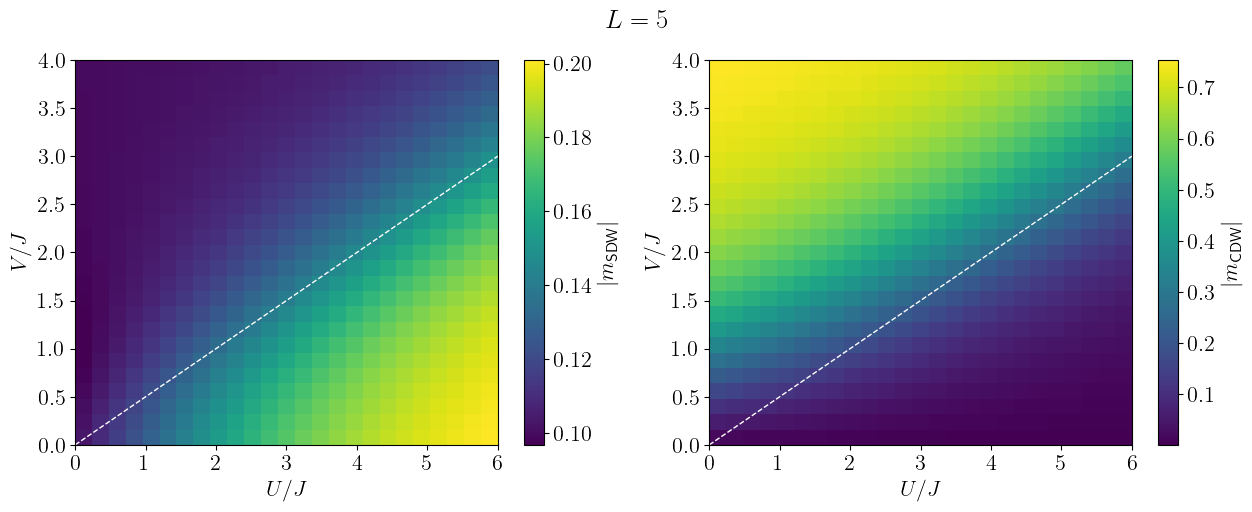

In [9]:
U_min_plot, U_max_plot = 0 , U_max
V_min_plot, V_max_plot = 0 , V_max

def select_region(U_vals, V_vals, data, U_min_plot, U_max_plot, V_min_plot, V_max_plot):
    U_mask = (U_vals >= U_min_plot) & (U_vals <= U_max_plot)
    V_mask = (V_vals >= V_min_plot) & (V_vals <= V_max_plot)
    return U_vals[U_mask], V_vals[V_mask], data[np.ix_(V_mask, U_mask)]

# Slice arrays
U_vals_plot, V_vals_plot, m_sdw_plot = select_region(U_vals, V_vals, m_sdw, U_min_plot, U_max_plot, V_min_plot, V_max_plot)
_, _, m_cdw_plot = select_region(U_vals, V_vals, m_cdw, U_min_plot, U_max_plot, V_min_plot, V_max_plot)

# Meshgrid for contours
X, Y = np.meshgrid(U_vals_plot, V_vals_plot)

# Plotting
fig, ax = plt.subplots(1, 2, figsize=(15, 5), sharex=True)
plt.suptitle(f"$L = {L}$")

# m_SDW
im0 = ax[0].imshow(m_sdw_plot, origin="lower", extent=[U_min_plot, U_max_plot, V_min_plot, V_max_plot], aspect="auto", cmap=theme)
fig.colorbar(im0, ax=ax[0], label=r"$|m_{\text{SDW}}|$")
# ax[0].contour(X, Y, np.abs(m_sdw_plot), colors='white', linestyle='--', linewidths=0.7)
ax[0].set_xlabel(r"$U / J$")
ax[0].set_ylabel(r"$V / J$")

# m_CDW
im1 = ax[1].imshow(m_cdw_plot, origin="lower", extent=[U_min_plot, U_max_plot, V_min_plot, V_max_plot], aspect="auto", cmap=theme)
fig.colorbar(im1, ax=ax[1], label=r"$|m_{\text{CDW}}|$")
# ax[1].contour(X, Y, np.abs(m_cdw_plot), colors='white', linestyle='--', linewidths=0.7)
ax[1].set_xlabel(r"$U / J$")
ax[1].set_ylabel(r"$V / J$")

# Line U = 2V
V_range = np.linspace(max(0, V_min_plot), min(U_max_plot / 2, V_max_plot), N_Points)
U_range = 2 * V_range
ax[0].plot(U_range, V_range, 'w--', linewidth=1)
ax[1].plot(U_range, V_range, 'w--', linewidth=1)

# Save and show
plt.savefig(f"{figures_path}/{model}_{exec}/order_parameters_L={L}_U={U_min_plot}-{U_max_plot}_V={V_min_plot}-{V_max_plot}.png", dpi=300, bbox_inches="tight")
plt.show()

#### Energy

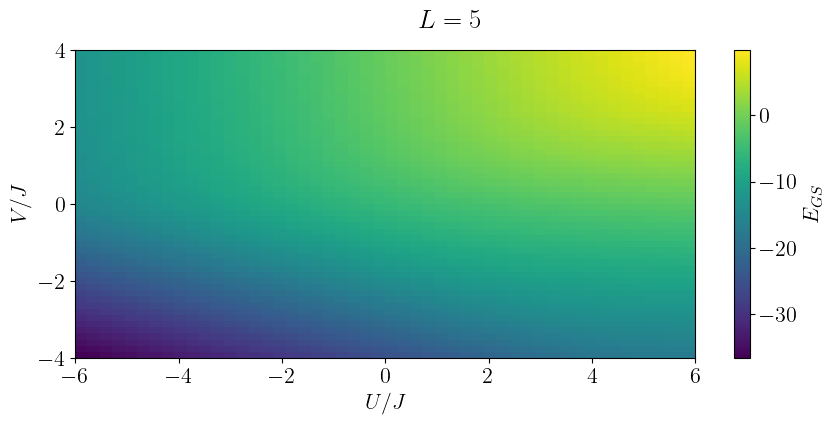

In [10]:
# Create a figure with two subplots
fig, ax = plt.subplots(1, 1, figsize=(10, 4), sharex=True)
    
im0 = ax.imshow(E_GS, origin="lower", extent=[U_min, U_max, V_min, V_max], aspect="auto", cmap=theme)
fig.colorbar(im0, ax=ax, label=r"$E_{GS}$")
ax.set_xlabel(r"$U / J$")
ax.set_ylabel(r"$V / J$")

# Plot line U = 2V
# V_range = np.linspace(0, U_max / 2, N_Points)
# U_range = 2 * V_range 
# ax.plot(U_range, V_range, 'w--', linewidth=1)  
plt.suptitle(f"$L = {L}$")
plt.show()
fig.savefig(f"{figures_path}/{model}_{exec}/E_GS={L}_{model}_NPoints={N_Points}.png", dpi = 500, bbox_inches='tight')

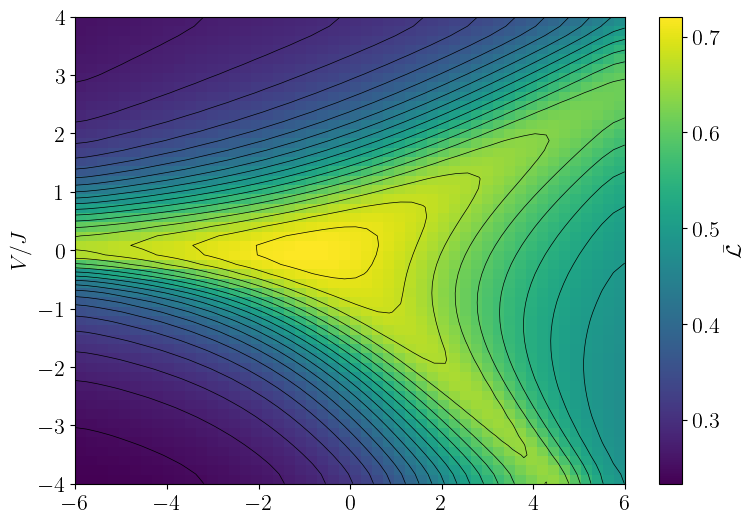

In [11]:
# Create a figure with two subplots
fig, ax1 = plt.subplots(1, 1 , figsize=(8, 6))

sigma_smoothing = 1.5
num_contour_levels = 20 # You can increase this to 30, 40, 50, etc.

avg_linear_entropy_smoothed = gaussian_filter(avg_linear_entropy, sigma=sigma_smoothing)

# Shared colorbar normalization - thanks chatgpt
# vmin = min(np.min(avg_linear_entropy), np.min(E_p))
# vmax = max(np.max(avg_linear_entropy), np.max(E_p))

U_min = np.min(U_vals)
U_max = np.max(U_vals)
V_min = np.min(V_vals)
V_max = np.max(V_max)

# Contour 
X, Y = np.meshgrid(U_vals, V_vals)

im0 = ax1.imshow(avg_linear_entropy, origin="lower", extent=[U_min, U_max, V_min, V_max], aspect="auto", cmap=theme)# , vmin=vmin, vmax=vmax)
fig.colorbar(im0, ax = ax1, orientation='vertical', label=r"$\bar{\mathcal{L}}$") # /\text{max}(\bar{\mathcal{L}})$")
ax1.contour(X, Y, avg_linear_entropy_smoothed, levels=num_contour_levels, colors='black', linewidths=0.5)

ax1.set_ylabel(r"$V / J$")
# ax1.set_title(r"$\mathcal{L}_i = 1 - \text{Tr}(\rho_i^2)$")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

fig.savefig(f"{figures_path}/{model}_{exec}/single_site_entanglement_L={L}_NPoints={N_Points}.png", dpi=100, bbox_inches='tight')
plt.show()

In [104]:
# --- Smoothing Parameters ---
# Sigma controls the degree of smoothing. Higher sigma means more smoothing.
# For a 50x50 grid, a sigma between 1 and 3 is often a good starting point.
# Experiment with this value to find what looks best for your data.

'''
sigma_smoothing = 1.5

# --- Contour Levels Parameter ---
# Number of contour lines you want to see.
# A higher number will result in more contour lines.
num_contour_levels = 20 # You can increase this to 30, 40, 50, etc.
# Alternatively, you can specify exact levels:
# custom_levels = np.linspace(E_p.min(), E_p.max(), num_contour_levels)

# Create a figure with two subplots
fig, ax1 = plt.subplots(2, 2, figsize=(13, 10))
plt.suptitle(f"$L = {L}$")

# Calculate min/max for extent from U_vals and V_vals
U_min = np.min(U_vals)
U_max = np.max(U_vals)
V_min = np.min(V_vals)
V_max = np.max(V_vals)

# Create meshgrid for contour plotting
X, Y = np.meshgrid(U_vals, V_vals)

# --- Plot 1: E_p ---
# Apply Gaussian filter for smoothing E_p data
E_p_smoothed = gaussian_filter(E_p, sigma=sigma_smoothing)

im1 = ax1[0, 0].imshow(E_p, origin="lower", extent=[U_min, U_max, V_min, V_max], aspect="auto", cmap=theme)
fig.colorbar(im1, ax=ax1[0, 0], orientation='vertical', label=r"$E_p$")
# Plot contours using the smoothed E_p data and specified number of levels
ax1[0, 0].contour(X, Y, E_p_smoothed, levels=num_contour_levels, colors='black', linewidths=0.5)
ax1[0, 0].set_xlabel(r"$U / J$")
ax1[0, 0].set_ylabel(r"$V / J$")
ax1[0, 0].set_title(r"$E_p = S(\rho_1) - \ln N$")

# --- Plot 2: quantum_coherence_1 ---
# Apply Gaussian filter for smoothing quantum_coherence_1 data
quantum_coherence_1_smoothed = gaussian_filter(quantum_coherence_1, sigma=sigma_smoothing)

im2 = ax1[0, 1].imshow(quantum_coherence_1, origin="lower", extent=[U_min, U_max, V_min, V_max], aspect="auto", cmap=theme)
fig.colorbar(im2, ax=ax1[0, 1], orientation='vertical', label=r"$C_1$")
# Plot contours using the smoothed quantum_coherence_1 data and specified number of levels
ax1[0, 1].contour(X, Y, quantum_coherence_1_smoothed, levels=num_contour_levels, colors='black', linewidths=0.5)
ax1[0, 1].set_xlabel(r"$U / J$")
ax1[0, 1].set_ylabel(r"$V / J$")
ax1[0, 1].set_title(r"$C_{\ell_1}(\hat{\rho}_1) = \sum_{i\neq j}|(\hat{\rho}_1)_{i, j}|$")

# --- Plot 3: Q_2 ---
# Apply Gaussian filter for smoothing Q_2 data
Q_2_smoothed = gaussian_filter(Q_2, sigma=sigma_smoothing)

im3 = ax1[1, 0].imshow(Q_2, origin="lower", extent=[U_min, U_max, V_min, V_max], aspect="auto", cmap=theme)
fig.colorbar(im3, ax=ax1[1, 0], orientation='vertical', label=r"$Q_2$")
# Plot contours using the smoothed Q_2 data and specified number of levels
ax1[1, 0].contour(X, Y, Q_2_smoothed, levels=num_contour_levels, colors='black', linewidths=0.5)
ax1[1, 0].set_xlabel(r"$U / J$")
ax1[1, 0].set_ylabel(r"$V / J$")
ax1[1, 0].set_title(r"$Q_2 = S(\rho_2) - \ln {N \choose 2}$")

# --- Plot 4: quantum_coherence_2 ---
# Apply Gaussian filter for smoothing quantum_coherence_2 data
quantum_coherence_2_smoothed = gaussian_filter(quantum_coherence_2, sigma=sigma_smoothing)

im4 = ax1[1, 1].imshow(quantum_coherence_2, origin="lower", extent=[U_min, U_max, V_min, V_max], aspect="auto", cmap=theme)
fig.colorbar(im4, ax=ax1[1, 1], orientation='vertical', label=r"$C_2$")
# Plot contours using the smoothed quantum_coherence_2 data and specified number of levels
ax1[1, 1].contour(X, Y, quantum_coherence_2_smoothed, levels=num_contour_levels, colors='black', linewidths=0.5)
ax1[1, 1].set_xlabel(r"$U / J$")
ax1[1, 1].set_ylabel(r"$V / J$")
ax1[1, 1].set_title(r"$C_{\ell_1}(\hat{\rho}_2)$")

# Adjust layout and save
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust rect to make space for suptitle
fig.savefig(f"{figures_path}/{model}_{exec}/entanglement_entropy_1_RDM_L={L}_NPoints={N_Points}.png", dpi=100, bbox_inches='tight')
plt.show()
'''

<>:39: SyntaxWarning: invalid escape sequence '\l'
<>:39: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_51491/1781413092.py:39: SyntaxWarning: invalid escape sequence '\l'
  ax1[0, 0].set_title(r"$E_p = S(\rho_1) - \ln N$")


'\nsigma_smoothing = 1.5\n\n# --- Contour Levels Parameter ---\n# Number of contour lines you want to see.\n# A higher number will result in more contour lines.\nnum_contour_levels = 20 # You can increase this to 30, 40, 50, etc.\n# Alternatively, you can specify exact levels:\n# custom_levels = np.linspace(E_p.min(), E_p.max(), num_contour_levels)\n\n# Create a figure with two subplots\nfig, ax1 = plt.subplots(2, 2, figsize=(13, 10))\nplt.suptitle(f"$L = {L}$")\n\n# Calculate min/max for extent from U_vals and V_vals\nU_min = np.min(U_vals)\nU_max = np.max(U_vals)\nV_min = np.min(V_vals)\nV_max = np.max(V_vals)\n\n# Create meshgrid for contour plotting\nX, Y = np.meshgrid(U_vals, V_vals)\n\n# --- Plot 1: E_p ---\n# Apply Gaussian filter for smoothing E_p data\nE_p_smoothed = gaussian_filter(E_p, sigma=sigma_smoothing)\n\nim1 = ax1[0, 0].imshow(E_p, origin="lower", extent=[U_min, U_max, V_min, V_max], aspect="auto", cmap=theme)\nfig.colorbar(im1, ax=ax1[0, 0], orientation=\'vertical\',

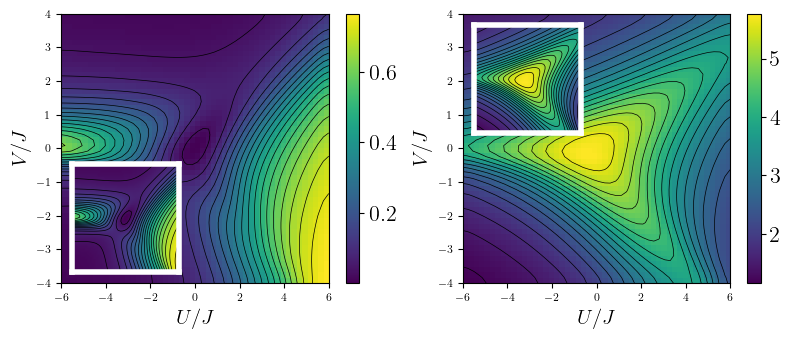

In [12]:
# --- parameters ---
sigma_smoothing    = 1.5
num_contour_levels = 20

# precompute extents & mesh
U_min, U_max = U_vals.min(), U_vals.max()
V_min, V_max = V_vals.min(), V_vals.max()
X, Y = np.meshgrid(U_vals, V_vals)

# helper to draw an imshow+contour
def draw_map(ax, data):
    sm = gaussian_filter(data, sigma=sigma_smoothing)
    im = ax.imshow(data, origin="lower",
                   extent=[U_min, U_max, V_min, V_max],
                   aspect="auto", cmap=theme)
    ax.contour(X, Y, sm, levels=num_contour_levels, colors='k', linewidths=0.5)
    ax.set_xlabel(r"$U/J$", fontsize=15)
    ax.set_ylabel(r"$V/J$", fontsize=15)
    ax.tick_params(labelsize=8)
    return im

# --- figure setup ---
fig, (axQ2, axC2) = plt.subplots(1, 2, figsize=(9.5, 3.5))

# main 1: Q2
imQ2 = draw_map(axQ2, Q_2)
fig.colorbar(imQ2, ax=axQ2, orientation='vertical') # , label=r"$Q_2$")

# inset for E_p
axins1 = inset_axes(axQ2, width="40%", height="40%", loc="lower left")

# give the inset a white background and white border
axins1.set_facecolor("white")
for spine in axins1.spines.values():
    spine.set_edgecolor("white")
    spine.set_linewidth(4)

draw_map(axins1, E_p)  # no title on inset
axins1.set_xticks([])
axins1.set_yticks([])

axins1.set_xlabel("")
axins1.set_ylabel("")

# main 2: C_l1(rho2)
imC2 = draw_map(axC2, quantum_coherence_2)
fig.colorbar(imC2, ax=axC2, orientation='vertical') # , label=r"$Q_2$")

# inset for C_l1(rho1)
axins2 = inset_axes(axC2, width="40%", height="40%", loc="upper left")

# same white frame on second inset
axins2.set_facecolor("white")
for spine in axins2.spines.values():
    spine.set_edgecolor("white")
    spine.set_linewidth(4)

draw_map(axins2, quantum_coherence_1)
axins2.set_xticks([])
axins2.set_yticks([])
axins2.set_xlabel("")
axins2.set_ylabel("")
# save & show
plt.savefig(f"{figures_path}/{model}_{exec}/big_Q2_C2_with_insets_L={L}.png", dpi=300, bbox_inches="tight")
plt.show()

#### Analysis of entanglement in accross different phases

In [13]:
V_targets_negatives = [-1.53, -1.32, -1.12, -0.92, -0.72]
V_targets_positives = [1.53, 2.32, 1.12, 0.92, 0.72]

U_targets_negatives = [-5.73, -4.75, -2.85, -1.76 ,-0.95, 0.0]
U_targets_positives = [2.3, 2.6, 1.9, 3.1, 4.3, 5.6]

#### Fixed $V$ values

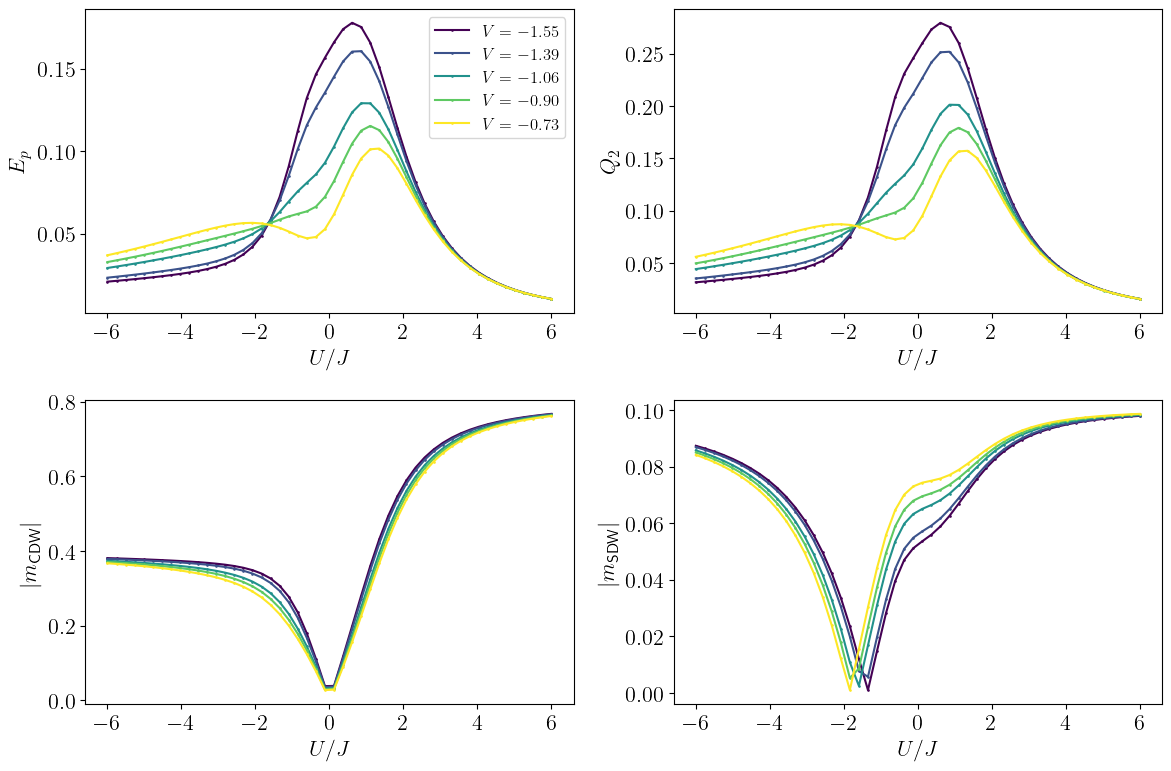

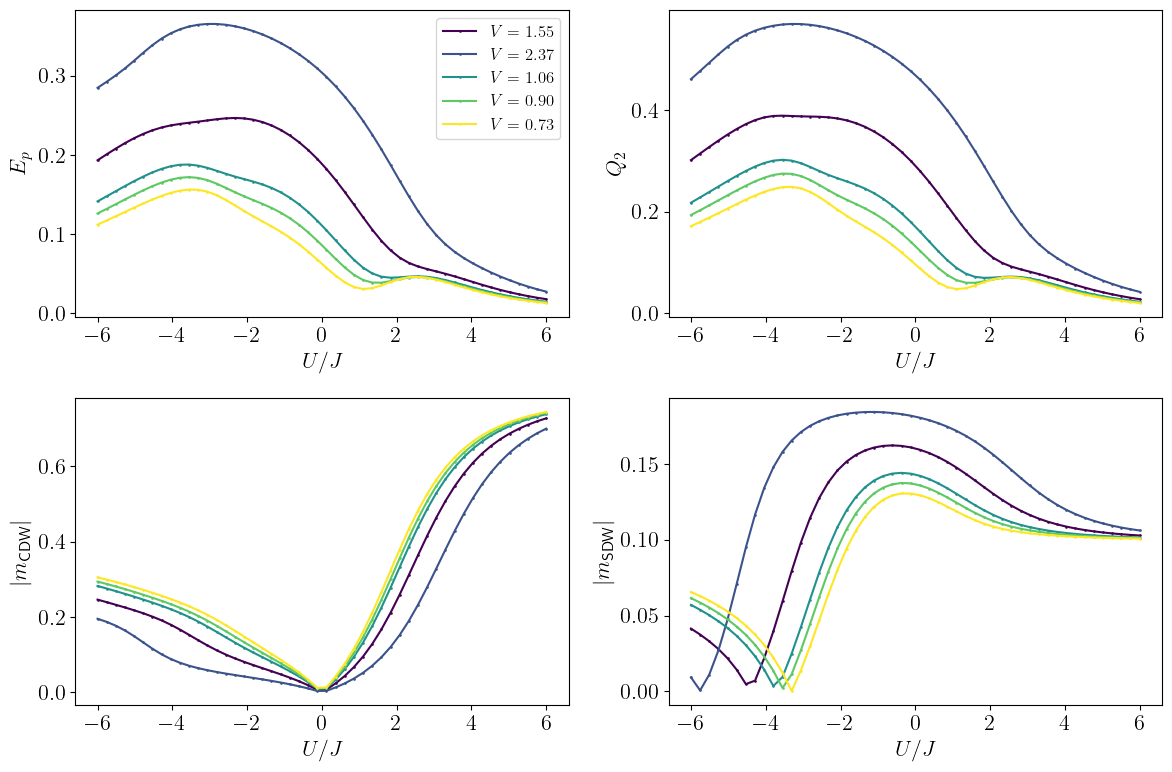

In [14]:
fig, ax = plt.subplots(2, 2, figsize=(12, 8))
# plt.suptitle(f"$L = {L}$")

colors_neg = cm.viridis(np.linspace(0, 1, len(V_targets_negatives)))

for color, V_target in zip(colors_neg, V_targets_negatives):
    i_V_fixed = np.argmin(np.abs(V_vals - V_target))
    ax[0, 0].plot(U_vals, E_p[:, i_V_fixed], 'o-', markersize=0.9, color=color, label=fr"$V={V_vals[i_V_fixed]:.2f}$")
    ax[0, 1].plot(U_vals, Q_2[:, i_V_fixed], 'o-', markersize=0.9, color=color)
    ax[1, 0].plot(U_vals, m_cdw[:, i_V_fixed], 'o-', markersize=0.9, color=color)
    ax[1, 1].plot(U_vals, m_sdw[:, i_V_fixed], 'o-', markersize=0.9, color=color)

ax[0, 0].set_xlabel(r"$U / J$")
ax[0, 1].set_xlabel(r"$U / J$")
ax[1, 0].set_xlabel(r"$U / J$")
ax[1, 1].set_xlabel(r"$U / J$")

ax[0, 0].set_ylabel(r"$E_p$")
ax[0, 1].set_ylabel(r"$Q_2$")
ax[1, 0].set_ylabel(r"$|m_{\text{CDW}}|$")
ax[1, 1].set_ylabel(r"$|m_{\text{SDW}}|$")

ax[0, 0].legend(fontsize=12)

plt.tight_layout()
fig.savefig(f"{figures_path}/{model}_{exec}/order_parameters_and_entanglement_measures_={L}_fixed_V_negative_.png",
            dpi=500, bbox_inches='tight')
plt.show()

# Positive V plots
fig, ax = plt.subplots(2, 2, figsize=(12, 8))

colors_pos = cm.viridis(np.linspace(0, 1, len(V_targets_positives)))

for color, V_target in zip(colors_pos, V_targets_positives):
    i_V_fixed = np.argmin(np.abs(V_vals - V_target))
    ax[0, 0].plot(U_vals, E_p[:, i_V_fixed], 'o-', markersize=0.9, color=color, label=fr"$V={V_vals[i_V_fixed]:.2f}$")
    ax[0, 1].plot(U_vals, Q_2[:, i_V_fixed], 'o-', markersize=0.9, color=color)
    ax[1, 0].plot(U_vals, m_cdw[:, i_V_fixed], 'o-', markersize=0.9, color=color)
    ax[1, 1].plot(U_vals, m_sdw[:, i_V_fixed], 'o-', markersize=0.9, color=color)

ax[0, 0].set_ylabel(r"$E_p$")
ax[0, 1].set_ylabel(r"$Q_2$")
ax[1, 0].set_ylabel(r"$|m_{\text{CDW}}|$")
ax[1, 1].set_ylabel(r"$|m_{\text{SDW}}|$")

ax[0, 0].set_xlabel(r"$U / J$")
ax[0, 1].set_xlabel(r"$U / J$")
ax[1, 0].set_xlabel(r"$U / J$")
ax[1, 1].set_xlabel(r"$U / J$")

ax[0, 0].legend(fontsize=12)

plt.tight_layout()
fig.savefig(f"{figures_path}/{model}_{exec}/order_parameters_and_entanglement_measures_={L}_fixed_V_positive_.png",
            dpi=500, bbox_inches='tight')
plt.show()

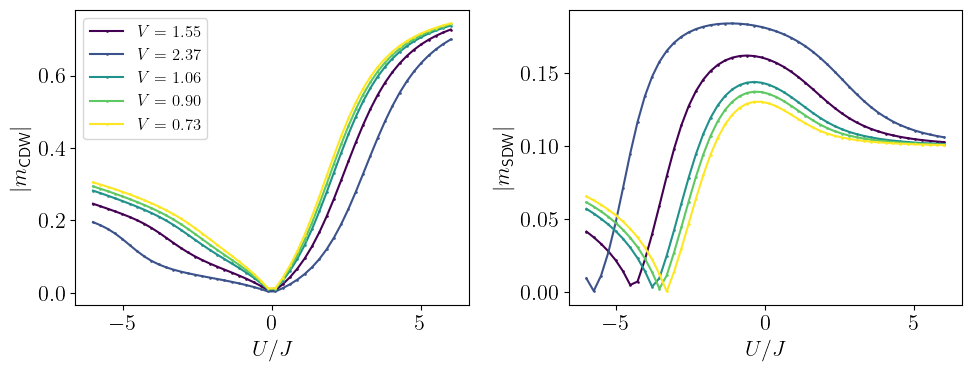

In [24]:
# Positive V plots
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

colors_pos = cm.viridis(np.linspace(0, 1, len(V_targets_positives)))

for color, V_target in zip(colors_pos, V_targets_positives):
    i_V_fixed = np.argmin(np.abs(V_vals - V_target))
    ax[0].plot(U_vals, m_cdw[:, i_V_fixed], 'o-', markersize=0.9, color=color, label=f"$V={V_vals[i_V_fixed]:.2f}$")
    ax[1].plot(U_vals, m_sdw[:, i_V_fixed], 'o-', markersize=0.9, color=color)

ax[0].set_ylabel(r"$|m_{\text{CDW}}|$")
ax[1].set_ylabel(r"$|m_{\text{SDW}}|$")

ax[0].set_xlabel(r"$U / J$")
ax[1].set_xlabel(r"$U / J$")

ax[0].legend(fontsize=12)

plt.tight_layout()
fig.savefig(f"{figures_path}/{model}_{exec}/order_parameters_={L}_fixed_V_positive_.png", dpi=500, bbox_inches='tight')
plt.show()

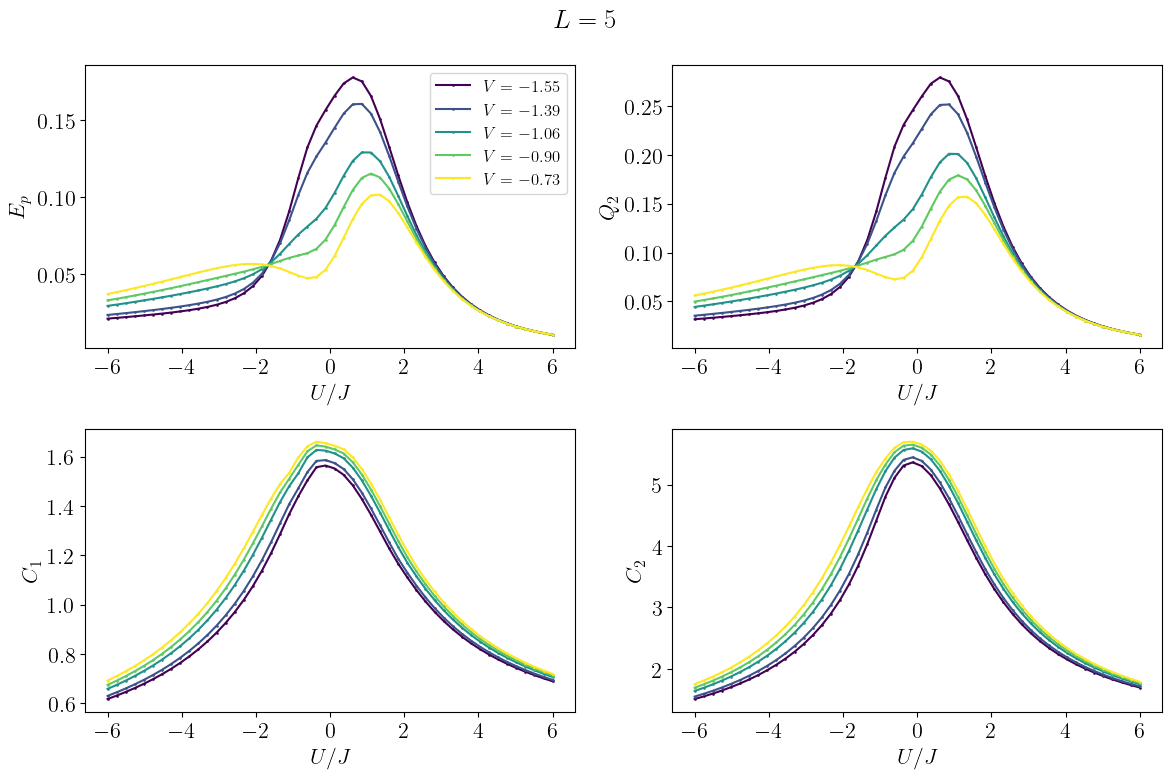

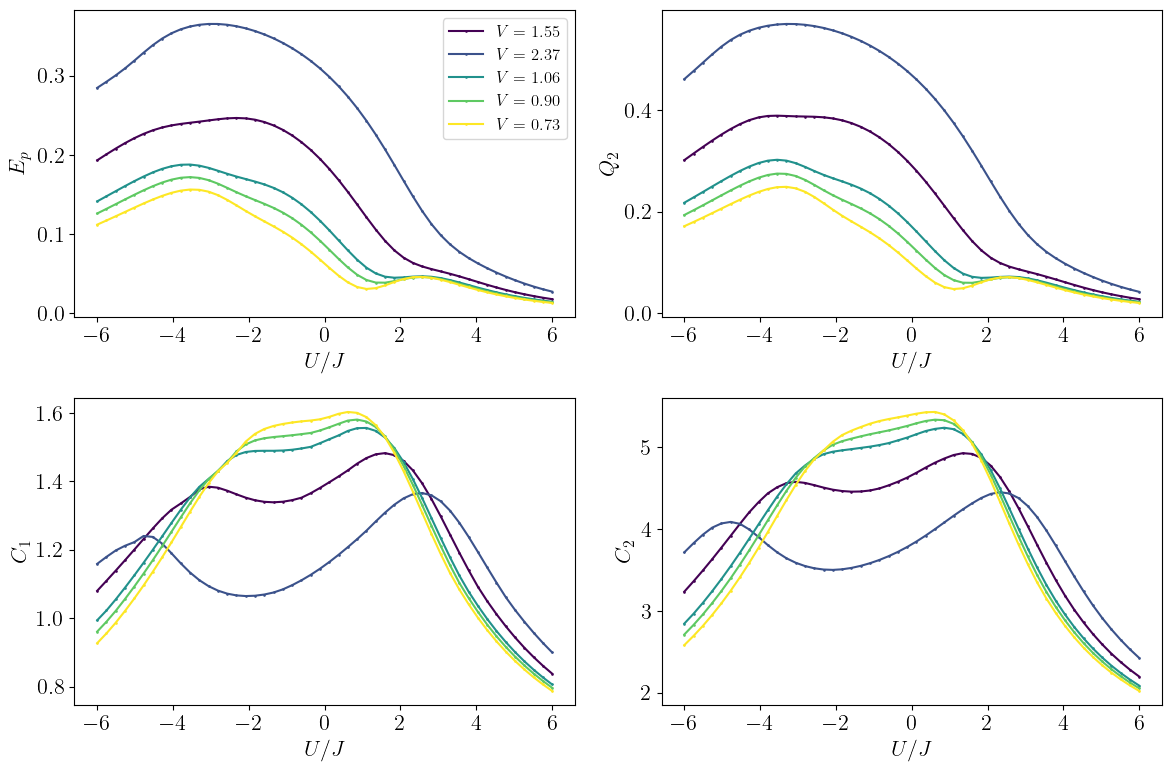

In [ ]:
colors_neg = cm.viridis(np.linspace(0, 1, len(V_targets_negatives)))

fig, ax = plt.subplots(2, 2, figsize=(12, 8))

for color, V_target in zip(colors_neg, V_targets_negatives):
    i_V_fixed = np.argmin(np.abs(V_vals - V_target))
    ax[0, 0].plot(U_vals, E_p[:, i_V_fixed], 'o-', markersize=0.9, color=color, label=fr"$V={V_vals[i_V_fixed]:.2f}$")
    ax[0, 1].plot(U_vals, Q_2[:, i_V_fixed], 'o-', markersize=0.9, color=color)
    ax[1, 0].plot(U_vals, quantum_coherence_1[:, i_V_fixed], 'o-', markersize=0.9, color=color)
    ax[1, 1].plot(U_vals, quantum_coherence_2[:, i_V_fixed], 'o-', markersize=0.9, color=color)

ax[0, 0].set_xlabel(r"$U / J$")
ax[0, 1].set_xlabel(r"$U / J$")
ax[1, 0].set_xlabel(r"$U / J$")
ax[1, 1].set_xlabel(r"$U / J$")

ax[0, 0].set_ylabel(r"$E_p$")
ax[0, 1].set_ylabel(r"$Q_2$")
ax[1, 0].set_ylabel(r"$C_1$")
ax[1, 1].set_ylabel(r"$C_2$")

ax[0, 0].legend(fontsize=12)

plt.tight_layout()
fig.savefig(f"{figures_path}/{model}_{exec}/entanglement_measures_={L}_fixed_V_negative_.png", dpi=500, bbox_inches='tight')
plt.show()



colors_pos = cm.viridis(np.linspace(0, 1, len(V_targets_positives)))

fig, ax = plt.subplots(2, 2, figsize=(12, 8))

for color, V_target in zip(colors_pos, V_targets_positives):
    i_V_fixed = np.argmin(np.abs(V_vals - V_target))
    ax[0, 0].plot(U_vals, E_p[:, i_V_fixed], 'o-', markersize=0.9, color=color, label=fr"$V={V_vals[i_V_fixed]:.2f}$")
    ax[0, 1].plot(U_vals, Q_2[:, i_V_fixed], 'o-', markersize=0.9, color=color)
    ax[1, 0].plot(U_vals, quantum_coherence_1[:, i_V_fixed], 'o-', markersize=0.9, color=color)
    ax[1, 1].plot(U_vals, quantum_coherence_2[:, i_V_fixed], 'o-', markersize=0.9, color=color)

ax[0, 0].set_ylabel(r"$E_p$")
ax[0, 1].set_ylabel(r"$Q_2$")
ax[1, 0].set_ylabel(r"$C_1$")
ax[1, 1].set_ylabel(r"$C_2$")

ax[0, 0].set_xlabel(r"$U / J$")
ax[0, 1].set_xlabel(r"$U / J$")
ax[1, 0].set_xlabel(r"$U / J$")
ax[1, 1].set_xlabel(r"$U / J$")

ax[0, 0].legend(fontsize=12)

plt.tight_layout()
fig.savefig(f"{figures_path}/{model}_{exec}/entanglement_measures_={L}_fixed_V_positive_.png", dpi=500, bbox_inches='tight')
plt.show()

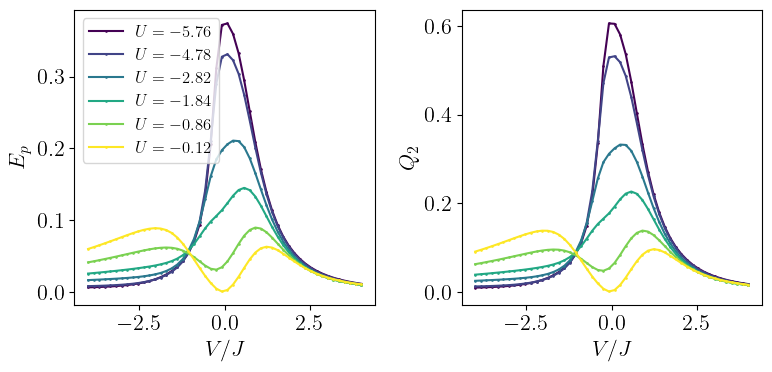

In [110]:
colors_neg = cm.viridis(np.linspace(0, 1, len(U_targets_negatives)))

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
for color, U_target in zip(colors_neg, U_targets_negatives):
    i_U_fixed = np.argmin(np.abs(U_vals - U_target))
    ax[0].plot(V_vals, E_p[:, i_U_fixed], 'o-', markersize=0.9, color=color, label=fr"$U={U_vals[i_U_fixed]:.2f}$")
    ax[1].plot(V_vals, Q_2[:, i_U_fixed], 'o-', markersize=0.9, color=color)

ax[0].set_xlabel(r"$V / J$")
ax[1].set_xlabel(r"$V / J$")
ax[0].set_ylabel(r"$E_p$")
ax[1].set_ylabel(r"$Q_2$")

ax[0].legend(fontsize=12)

plt.tight_layout()
fig.savefig(f"{figures_path}/{model}_{exec}/von_neumann_one_two_rdm={L}_fixed_U_negative_.png",
            dpi=500, bbox_inches='tight')
plt.show()

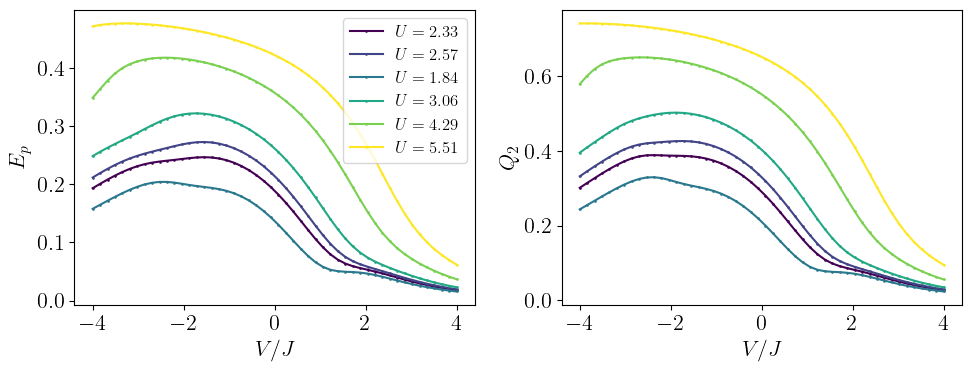

In [111]:
colors_pos = cm.viridis(np.linspace(0, 1, len(U_targets_positives)))

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
# plt.suptitle(f"$L = {L}$")

for color, U_target in zip(colors_pos, U_targets_positives):
    i_U_fixed = np.argmin(np.abs(U_vals - U_target))
    ax[0].plot(V_vals, E_p[:, i_U_fixed], 'o-', markersize=0.9, color=color, label=fr"$U={U_vals[i_U_fixed]:.2f}$")
    ax[1].plot(V_vals, Q_2[:, i_U_fixed], 'o-', markersize=0.9, color=color)

ax[0].set_xlabel(r"$V / J$")
ax[1].set_xlabel(r"$V / J$")

ax[0].set_ylabel(r"$E_p$")
ax[1].set_ylabel(r"$Q_2$")

ax[0].legend(fontsize=12)

plt.tight_layout()
fig.savefig(f"{figures_path}/{model}_{exec}/von_neumann_one_two_rdm={L}_fixed_U_positive_.png", dpi=500, bbox_inches='tight')
plt.show()

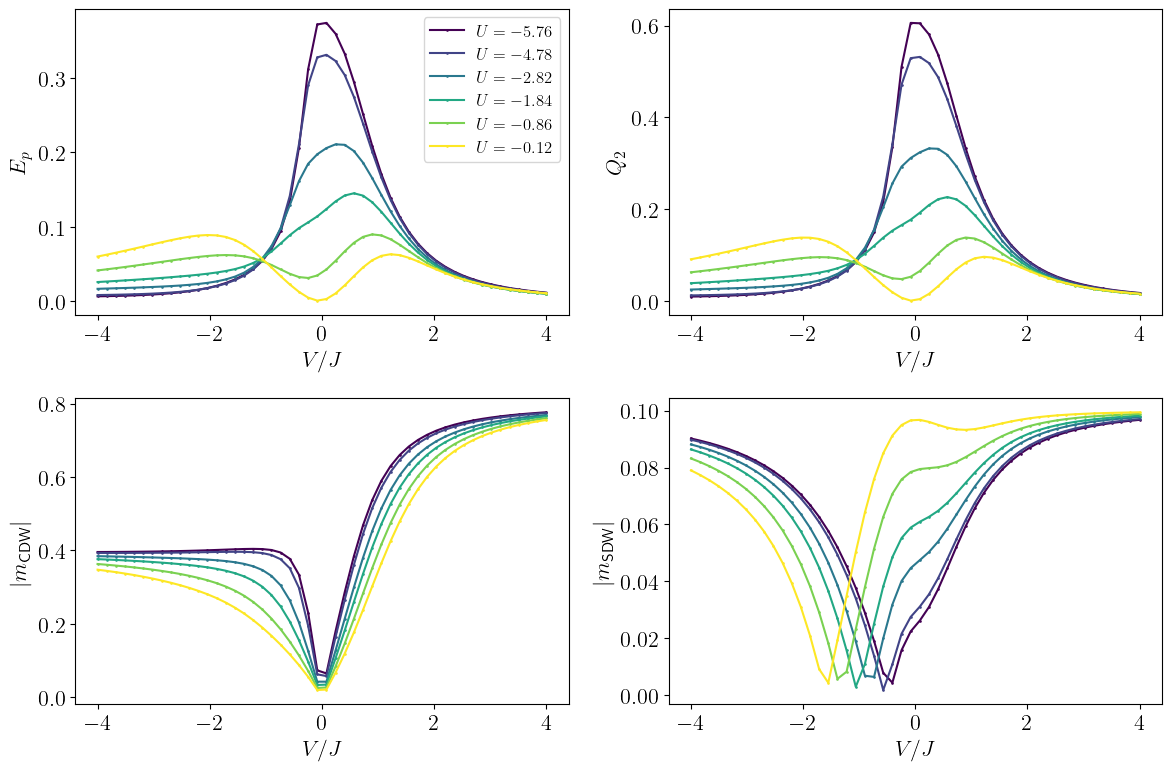

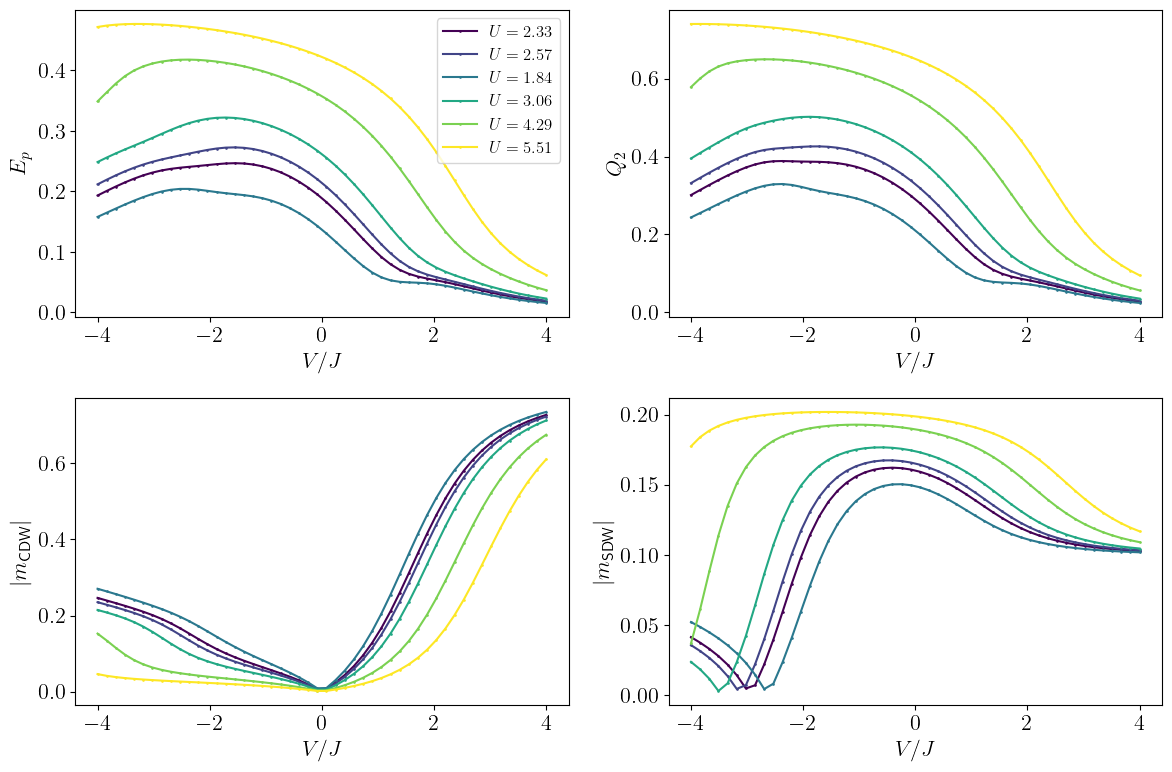

In [112]:
colors_neg = cm.viridis(np.linspace(0, 1, len(U_targets_negatives)))

fig, ax = plt.subplots(2, 2, figsize=(12, 8))
# plt.suptitle(f"$L = {L}$")

for color, U_target in zip(colors_neg, U_targets_negatives):
    i_U_fixed = np.argmin(np.abs(U_vals - U_target))
    ax[0, 0].plot(V_vals, E_p[:, i_U_fixed], 'o-', markersize=0.9, color=color,
                  label=fr"$U={U_vals[i_U_fixed]:.2f}$")
    ax[0, 1].plot(V_vals, Q_2[:, i_U_fixed], 'o-', markersize=0.9, color=color)
    ax[1, 0].plot(V_vals, m_cdw[:, i_U_fixed], 'o-', markersize=0.9, color=color)
    ax[1, 1].plot(V_vals, m_sdw[:, i_U_fixed], 'o-', markersize=0.9, color=color)

ax[0, 0].set_xlabel(r"$V / J$")
ax[0, 1].set_xlabel(r"$V / J$")
ax[1, 0].set_xlabel(r"$V / J$")
ax[1, 1].set_xlabel(r"$V / J$")

ax[0, 0].set_ylabel(r"$E_p$")
ax[0, 1].set_ylabel(r"$Q_2$")
ax[1, 0].set_ylabel(r"$|m_{\text{CDW}}|$")
ax[1, 1].set_ylabel(r"$|m_{\text{SDW}}|$")

ax[0, 0].legend(fontsize=12)

plt.tight_layout()
fig.savefig(f"{figures_path}/{model}_{exec}/order_parameters_and_entanglement_measures_={L}_fixed_U_negative_.png",
            dpi=500, bbox_inches='tight')
plt.show()


colors_pos = cm.viridis(np.linspace(0, 1, len(U_targets_positives)))

fig, ax = plt.subplots(2, 2, figsize=(12, 8))
# plt.suptitle(f"$L = {L}$")

for color, U_target in zip(colors_pos, U_targets_positives):
    i_U_fixed = np.argmin(np.abs(U_vals - U_target))
    ax[0, 0].plot(V_vals, E_p[:, i_U_fixed], 'o-', markersize=0.9, color=color,
                  label=fr"$U={U_vals[i_U_fixed]:.2f}$")
    ax[0, 1].plot(V_vals, Q_2[:, i_U_fixed], 'o-', markersize=0.9, color=color)
    ax[1, 0].plot(V_vals, m_cdw[:, i_U_fixed], 'o-', markersize=0.9, color=color)
    ax[1, 1].plot(V_vals, m_sdw[:, i_U_fixed], 'o-', markersize=0.9, color=color)

ax[0, 0].set_xlabel(r"$V / J$")
ax[0, 1].set_xlabel(r"$V / J$")
ax[1, 0].set_xlabel(r"$V / J$")
ax[1, 1].set_xlabel(r"$V / J$")

ax[0, 0].set_ylabel(r"$E_p$")
ax[0, 1].set_ylabel(r"$Q_2$")
ax[1, 0].set_ylabel(r"$|m_{\text{CDW}}|$")
ax[1, 1].set_ylabel(r"$|m_{\text{SDW}}|$")

ax[0, 0].legend(fontsize=12)

plt.tight_layout()
fig.savefig(f"{figures_path}/{model}_{exec}/order_parameters_and_entanglement_measures_={L}_fixed_U_positive_.png",
            dpi=500, bbox_inches='tight')
plt.show()

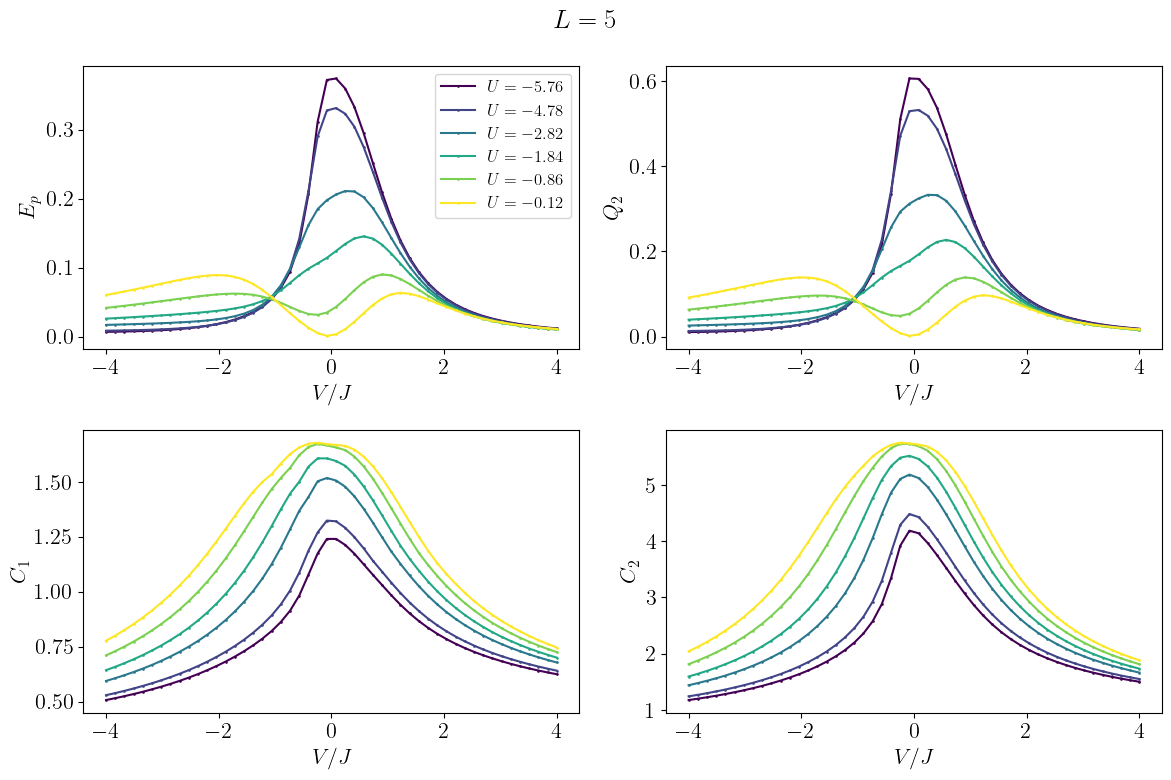

In [ ]:
colors_neg = cm.viridis(np.linspace(0, 1, len(U_targets_negatives)))

fig, ax = plt.subplots(2, 2, figsize=(12, 8))

for color, U_target in zip(colors_neg, U_targets_negatives):
    i_U_fixed = np.argmin(np.abs(U_vals - U_target))
    ax[0, 0].plot(V_vals, E_p[:, i_U_fixed], 'o-', markersize=0.9, color=color,
                  label=fr"$U={U_vals[i_U_fixed]:.2f}$")
    ax[0, 1].plot(V_vals, Q_2[:, i_U_fixed], 'o-', markersize=0.9, color=color)
    ax[1, 0].plot(V_vals, quantum_coherence_1[:, i_U_fixed], 'o-', markersize=0.9, color=color)
    ax[1, 1].plot(V_vals, quantum_coherence_2[:, i_U_fixed], 'o-', markersize=0.9, color=color)

ax[0, 0].set_xlabel(r"$V / J$")
ax[0, 1].set_xlabel(r"$V / J$")
ax[1, 0].set_xlabel(r"$V / J$")
ax[1, 1].set_xlabel(r"$V / J$")

ax[0, 0].set_ylabel(r"$E_p$")
ax[0, 1].set_ylabel(r"$Q_2$")
ax[1, 0].set_ylabel(r"$C_1$")
ax[1, 1].set_ylabel(r"$C_2$")

ax[0, 0].legend(fontsize=12)

plt.tight_layout()
fig.savefig(f"{figures_path}/{model}_{exec}/entanglement_measures_={L}_fixed_U_negative_.png",
            dpi=500, bbox_inches='tight')
plt.show()


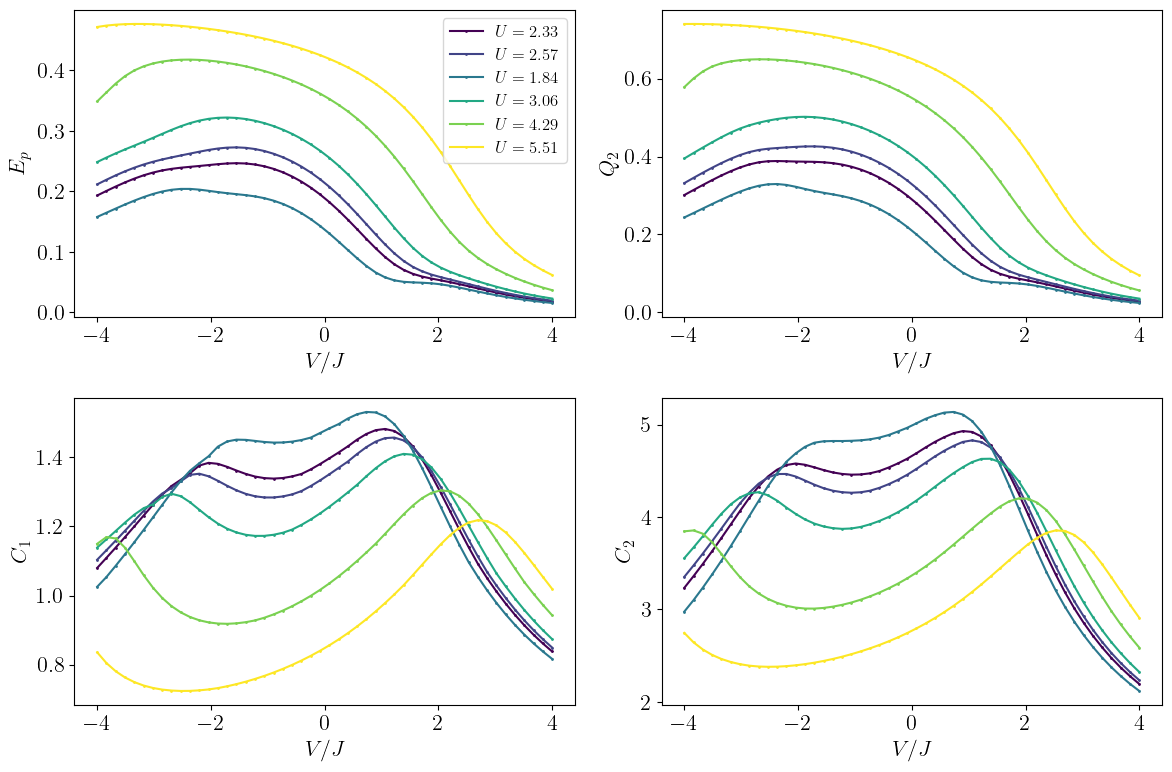

In [16]:
colors_pos = cm.viridis(np.linspace(0, 1, len(U_targets_positives)))

fig, ax = plt.subplots(2, 2, figsize=(12, 8))
# plt.suptitle(f"$L = {L}$")

for color, U_target in zip(colors_pos, U_targets_positives):
    i_U_fixed = np.argmin(np.abs(U_vals - U_target))
    ax[0, 0].plot(V_vals, E_p[:, i_U_fixed], 'o-', markersize=1.0, color=color,
                  label=fr"$U={U_vals[i_U_fixed]:.2f}$")
    ax[0, 1].plot(V_vals, Q_2[:, i_U_fixed], 'o-', markersize=1.0, color=color)
    ax[1, 0].plot(V_vals, quantum_coherence_1[:, i_U_fixed], 'o-', markersize=1.0, color=color)
    ax[1, 1].plot(V_vals, quantum_coherence_2[:, i_U_fixed], 'o-', markersize=1.0, color=color)

ax[0, 0].set_xlabel(r"$V / J$")
ax[0, 1].set_xlabel(r"$V / J$")
ax[1, 0].set_xlabel(r"$V / J$")
ax[1, 1].set_xlabel(r"$V / J$")

ax[0, 0].set_ylabel(r"$E_p$")
ax[0, 1].set_ylabel(r"$Q_2$")
ax[1, 0].set_ylabel(r"$C_1$")
ax[1, 1].set_ylabel(r"$C_2$")

ax[0, 0].legend(fontsize=12)

plt.tight_layout()
fig.savefig(f"{figures_path}/{model}_{exec}/entanglement_measures_={L}_fixed_U_positive_.png",
            dpi=500, bbox_inches='tight')
plt.show()

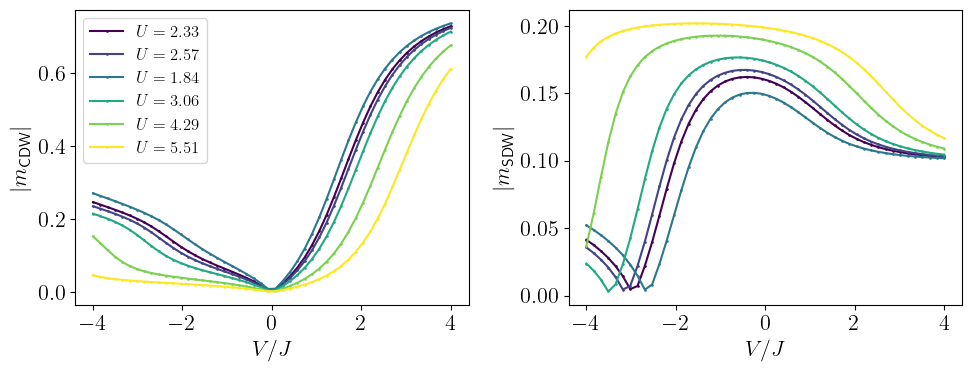

In [22]:
colors_pos = cm.viridis(np.linspace(0, 1, len(U_targets_positives)))

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
# plt.suptitle(f"$L = {L}$")

for color, U_target in zip(colors_pos, U_targets_positives):
    i_U_fixed = np.argmin(np.abs(U_vals - U_target))
    ax[0].plot(V_vals, m_cdw[:, i_U_fixed], 'o-', markersize=0.9, color=color, label=fr"$U={U_vals[i_U_fixed]:.2f}$")
    ax[1].plot(V_vals, m_sdw[:, i_U_fixed], 'o-', markersize=0.9, color=color, label=fr"$U={U_vals[i_U_fixed]:.2f}$")

ax[0].set_xlabel(r"$V / J$")
ax[1].set_xlabel(r"$V / J$")

ax[0].set_ylabel(r"$|m_{\text{CDW}}|$")
ax[1].set_ylabel(r"$|m_{\text{SDW}}|$")

ax[0].legend(fontsize=12)

plt.tight_layout()
fig.savefig(f"{figures_path}/{model}_{exec}/order_parameters_={L}_fixed_U_positive_.png", dpi=500, bbox_inches='tight')
plt.show()